In [1]:
import glob
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from cycler import cycler
import seaborn
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\from_gpu_server\tensorboard_logs\optuna\optuna_apr6_env1_a2c\A2C_1\events.out.tfevents.1744023613.gpu1.1088066.40
['C:', 'Users', 'choton', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Codes', 'for_coRL', 'from_gpu_server', 'tensorboard_logs', 'optuna', 'optuna_apr6_env1_a2c', 'A2C_1', 'events.out.tfevents.1744023613.gpu1.1088066.40']
['A2C', '1']

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\from_gpu_server\tensorboard_logs\optuna\optuna_apr6_env1_a2c\A2C_10\events.out.tfevents.1744029337.gpu1.1088066.49
['C:', 'Users', 'choton', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Codes', 'for_coRL', 'from_gpu_server', 'tensorboard_logs', 'optuna', 'optuna_apr6_env1_a2c', 'A2C_10',

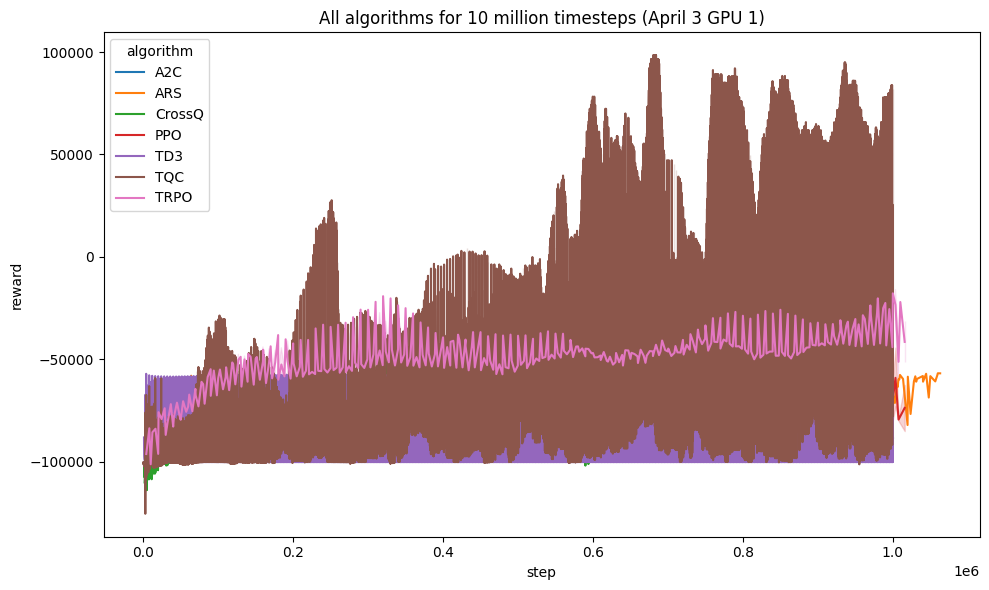

In [2]:
# Gather data
data = []
logs = glob.glob(r"C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\from_gpu_server\tensorboard_logs\optuna\*\*\*")
for log in logs:
    print(log)
    print(log.split('\\'))
    experiment_info = log.split('\\')[-2].split('_')
    print(experiment_info)
    algorithm = experiment_info[0]
    st = experiment_info[1]

    for e in tf.compat.v1.train.summary_iterator(log):
        for v in e.summary.value:
            if v.tag == 'rollout/ep_rew_mean':
                data.append({
                    'algorithm': algorithm,
                    'set': st,
                    'step': e.step,
                    'reward': v.simple_value
                })
df = pd.DataFrame(data)

# Plot algorithm comparison figure
plt.figure(figsize=(10,6))
plt.title('All algorithms for 10 million timesteps (April 3 GPU 1)')
seaborn.lineplot(data=df, x='step', y='reward', hue='algorithm')
# plt.grid()
plt.tight_layout()
# plt.savefig('a2c.png')
plt.show()

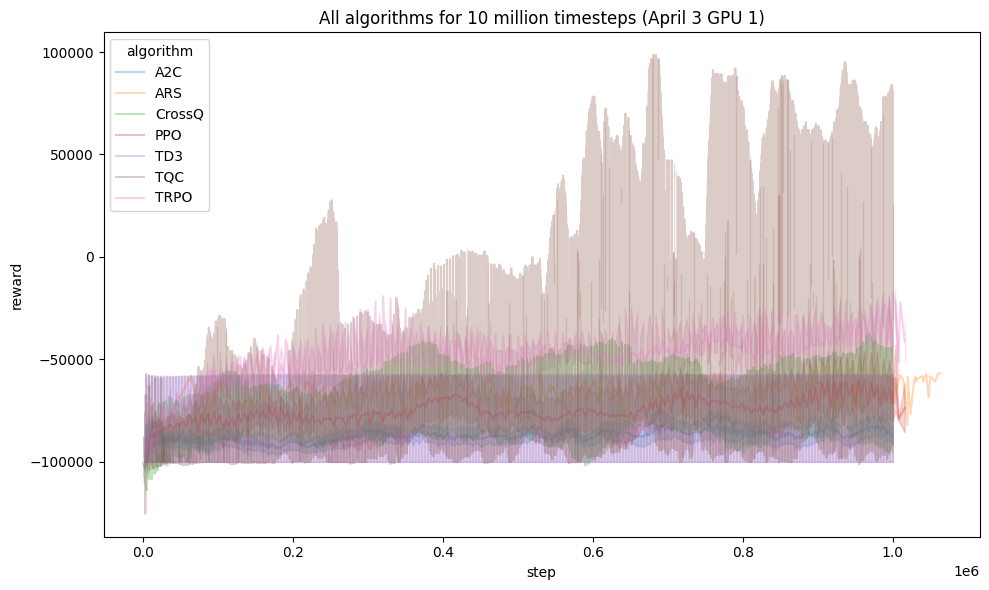

In [4]:
# Plot algorithm comparison figure
plt.figure(figsize=(10,6))
plt.title('All algorithms for 10 million timesteps (April 3 GPU 1)')
seaborn.lineplot(data=df, x='step', y='reward', hue='algorithm', alpha=0.3)
# plt.grid()
plt.tight_layout()
# plt.savefig('a2c.png')
plt.show()

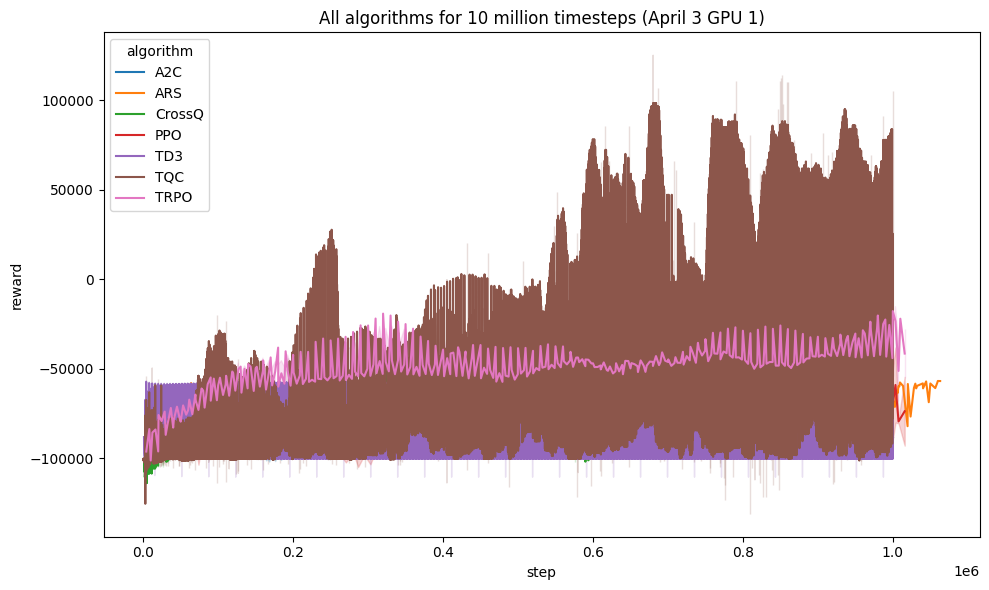

In [6]:
# Plot algorithm comparison figure
plt.figure(figsize=(10,6))
plt.title('All algorithms for 10 million timesteps (April 3 GPU 1)')
seaborn.lineplot(data=df, x='step', y='reward', hue='algorithm', errorbar='sd')
# plt.grid()
plt.tight_layout()
# plt.savefig('a2c.png')
plt.show()

In [19]:
from rliable import library as rly
from rliable import metrics
from rliable import plot_utils

In [22]:
set(df['algorithm'])

{'A2C', 'ARS', 'CrossQ', 'PPO', 'TD3', 'TQC', 'TRPO'}

In [30]:
df

,algorithm,set,step,reward,reward_smooth
0,A2C,1,8000,-56773.875000,-56773.875000
1,A2C,1,16000,-59396.187500,-58085.031250
2,A2C,1,24000,-74377.875000,-63515.979167
3,A2C,1,32000,-80084.031250,-67657.992188
4,A2C,1,40000,-77173.304688,-69561.054688
...,...,...,...,...,...
64302,TRPO,9,987136,-23478.099609,-27424.403125
64303,TRPO,9,991232,-22221.509766,-26022.875977
64304,TRPO,9,995328,-20095.619141,-24944.125977
64305,TRPO,9,999424,-19935.750000,-24339.731055


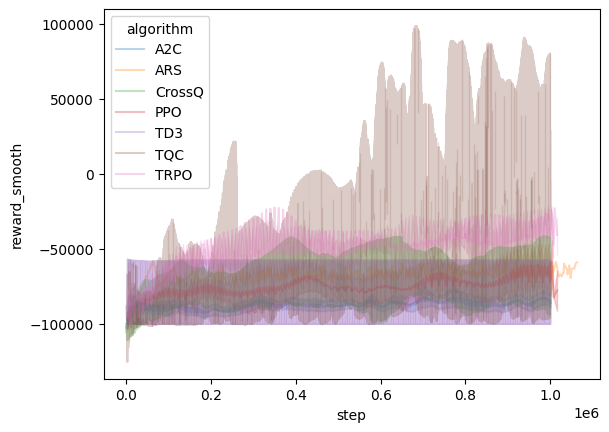

In [4]:
df['reward_smooth'] = df.groupby(['algorithm', 'set'])['reward'].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
)

seaborn.lineplot(data=df, x='step', y='reward_smooth', hue='algorithm', alpha=0.3)
plt.show()

In [5]:
df.to_csv("hyperparameter_results_n.csv")

In [ ]:
algorithms = set(df['algorithm'])
# Load ALE scores as a dictionary mapping algorithms to their human normalized
# score matrices across all 200 million frames, each of which is of size
# `(num_runs x num_games x 200)` where scores are recorded every million frame.
ale_all_frames_scores_dict = ...
frames = np.array([1, 10, 25, 50, 75, 100, 125, 150, 175, 200]) - 1
ale_frames_scores_dict = {algorithm: score[:, :, frames] for algorithm, score
                          in ale_all_frames_scores_dict.items()}
iqm = lambda scores: np.array([metrics.aggregate_iqm(scores[..., frame])
                               for frame in range(scores.shape[-1])])
iqm_scores, iqm_cis = rly.get_interval_estimates(
  ale_frames_scores_dict, iqm, reps=50000)
plot_utils.plot_sample_efficiency_curve(
    frames+1, iqm_scores, iqm_cis, algorithms=algorithms,
    xlabel=r'Number of Frames (in millions)',
    ylabel='IQM Human Normalized Score')

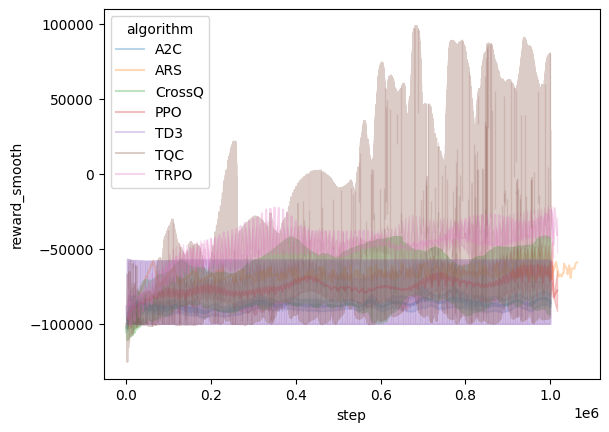

In [29]:
df['reward_smooth'] = df.groupby(['algorithm', 'set'])['reward'].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
)

seaborn.lineplot(data=df, x='step', y='reward_smooth', hue='algorithm', alpha=0.3)
plt.show()

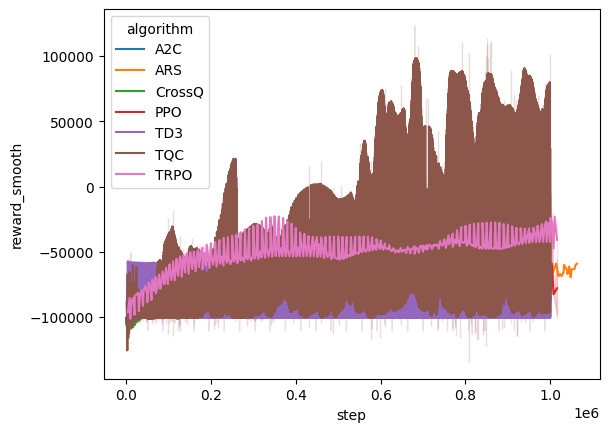

In [36]:
seaborn.lineplot(data=df, x='step', y='reward_smooth', hue='algorithm', errorbar='sd')
plt.show()

C:\Users\choton\AppData\Local\Temp\ipykernel_19728\891986932.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  seaborn.lineplot(data=df_reduced, x='step', y='reward', hue='algorithm', ci='sd', linewidth=2)


<Axes: xlabel='step', ylabel='reward'>

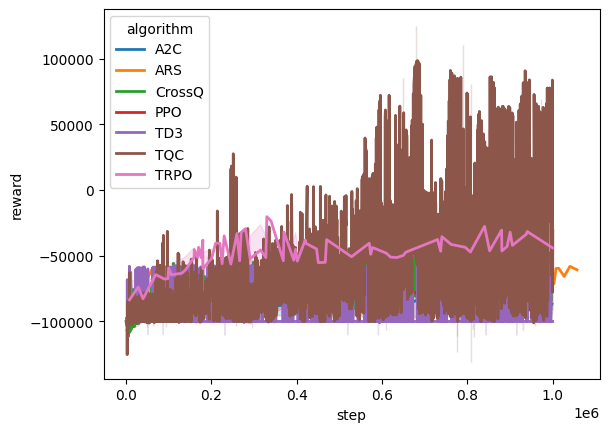

In [26]:
df_reduced = df.groupby(['algorithm', 'step'])['reward'].mean().reset_index()

# Keep every Nth step (e.g., every 5th unique step)
steps_to_keep = df_reduced['step'].drop_duplicates().sort_values().iloc[::5]
df_reduced = df[df['step'].isin(steps_to_keep)]

seaborn.lineplot(data=df_reduced, x='step', y='reward', hue='algorithm', ci='sd', linewidth=2)

In [13]:
df_reduced = df.groupby(['algorithm', 'set'], group_keys=False).apply(lambda x: x.iloc[::10])

C:\Users\choton\AppData\Local\Temp\ipykernel_19728\2550889714.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reduced = df.groupby(['algorithm', 'set'], group_keys=False).apply(lambda x: x.iloc[::10])


In [14]:
df_reduced

,algorithm,set,step,reward,reward_smooth
0,A2C,1,8000,-56773.875000,-56773.875000
10,A2C,1,88000,-87601.460938,-79932.321875
20,A2C,1,168000,-103241.476562,-90247.581250
30,A2C,1,248000,-89583.406250,-99038.739062
40,A2C,1,328000,-97465.507812,-94719.884375
...,...,...,...,...,...
64262,TRPO,9,823296,-29045.589844,-32626.792773
64272,TRPO,9,864256,-44759.820312,-36933.008203
64282,TRPO,9,905216,-46771.980469,-48467.114844
64292,TRPO,9,946176,-36659.738281,-40882.406641


C:\Users\choton\AppData\Local\Temp\ipykernel_19728\4906448.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.iloc[::50])


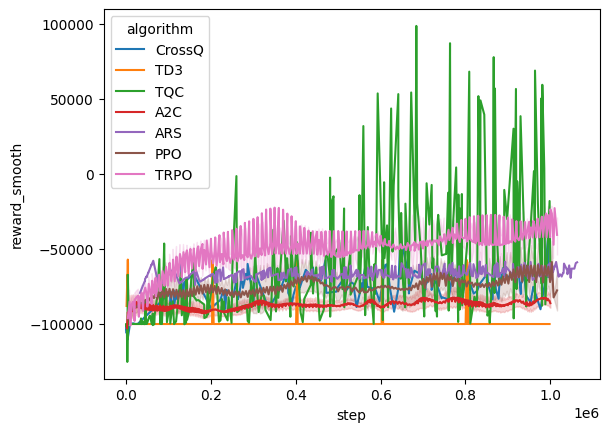

In [34]:
algos_to_downsample = ["TQC", "TD3", "CrossQ"]

# Downsample selected algorithms
df_downsampled = (
    df[df['algorithm'].isin(algos_to_downsample)]
    .groupby(['algorithm', 'set'], group_keys=False)
    .apply(lambda x: x.iloc[::50])
)

# Keep the rest as-is
df_rest = df[~df['algorithm'].isin(algos_to_downsample)]

# Combine
df_combined = pd.concat([df_downsampled, df_rest])
seaborn.lineplot(data=df_combined, x='step', y='reward_smooth', hue='algorithm')
plt.show()

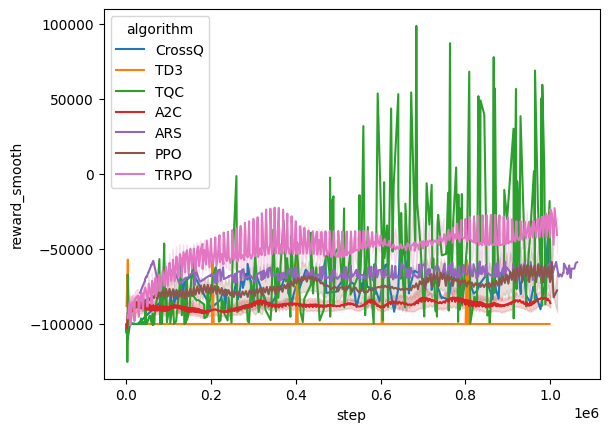

In [38]:
seaborn.lineplot(data=df_combined, x='step', y='reward_smooth', hue='algorithm')
plt.show()

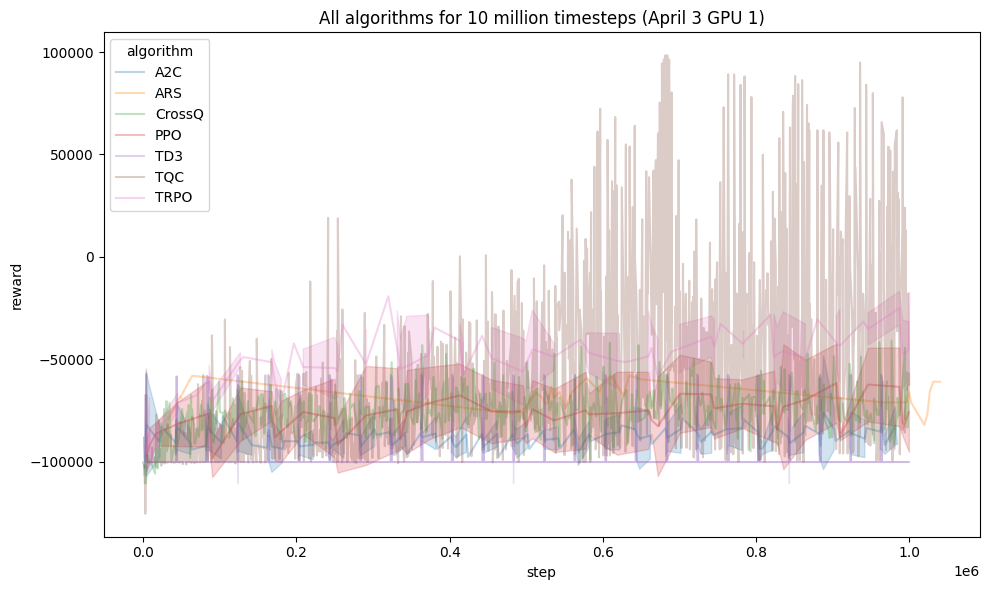

In [15]:
# Plot algorithm comparison figure
plt.figure(figsize=(10,6))
plt.title('All algorithms for 10 million timesteps (April 3 GPU 1)')
seaborn.lineplot(data=df_reduced, x='step', y='reward', hue='algorithm', errorbar='sd', alpha=0.3)
# plt.grid()
plt.tight_layout()
# plt.savefig('a2c.png')
plt.show()

C:\Users\choto\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\march25_kaos_logs\new_mar25_env1_ars\ARS_1\events.out.tfevents.1742966196.kaos5-1.23948.3
['C:', 'Users', 'choto', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Codes', 'for_coRL', 'march25_kaos_logs', 'new_mar25_env1_ars', 'ARS_1', 'events.out.tfevents.1742966196.kaos5-1.23948.3']
['ARS', '1']
C:\Users\choto\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\march25_kaos_logs\new_mar25_env1_CrossQ\CrossQ_1\events.out.tfevents.1742969869.kaos5-1.23948.4
['C:', 'Users', 'choto', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Codes', 'for_coRL', 'march25_kaos_logs', 'new_mar25_env1_CrossQ', 'CrossQ_1', 'events.out.tfevents.1742969869.kaos5-1.23948.4']
['CrossQ', '1']
C:\Users\choto\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\march25_kaos_logs\ne

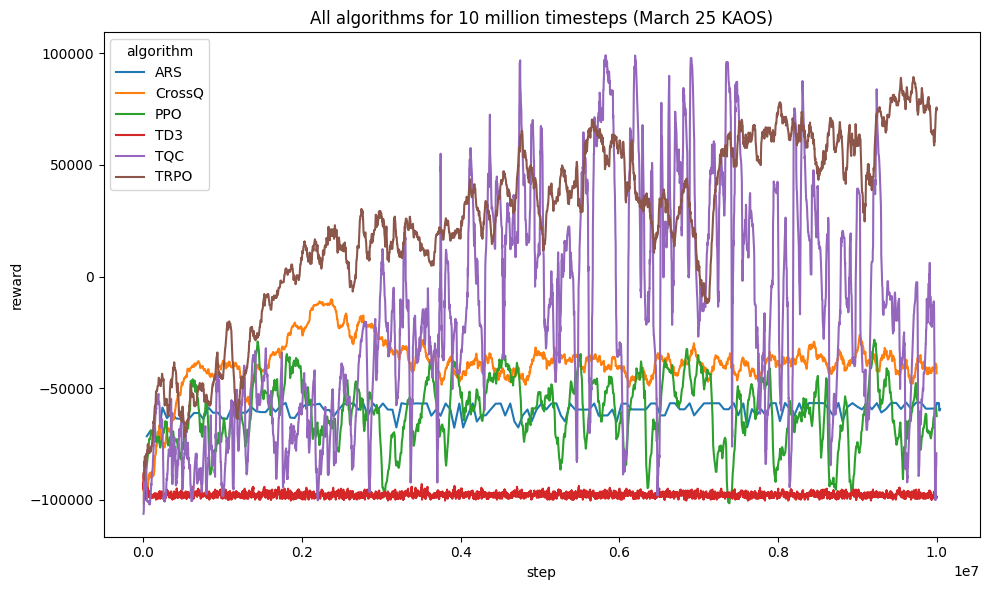

In [6]:
# Gather data
data = []
logs = glob.glob(r"C:\Users\choto\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\march25_kaos_logs\*\*\*")
for log in logs:
    print(log)
    print(log.split('\\'))
    experiment_info = log.split('\\')[-2].split('_')
    print(experiment_info)
    algorithm = experiment_info[0]
    st = experiment_info[1]

    for e in tf.compat.v1.train.summary_iterator(log):
        for v in e.summary.value:
            if v.tag == 'rollout/ep_rew_mean':
                data.append({
                    'algorithm': algorithm,
                    'set': st,
                    'step': e.step,
                    'reward': v.simple_value
                })
df = pd.DataFrame(data)

# Plot algorithm comparison figure
plt.figure(figsize=(10,6))
plt.title('All algorithms for 10 million timesteps (March 25 KAOS)')
seaborn.lineplot(data=df, x='step', y='reward', hue='algorithm')
# plt.grid()
plt.tight_layout()
# plt.savefig('a2c.png')
plt.show()

C:\Users\choto\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\from_gpu_server\march31\new_mar31_env1_a2c\A2C_1\events.out.tfevents.1743460273.gpu1.323481.3
['C:', 'Users', 'choto', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Codes', 'for_coRL', 'from_gpu_server', 'march31', 'new_mar31_env1_a2c', 'A2C_1', 'events.out.tfevents.1743460273.gpu1.323481.3']
['A2C', '1']
C:\Users\choto\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\from_gpu_server\march31\new_mar31_env1_ars\ARS_1\events.out.tfevents.1743457971.gpu1.323481.2
['C:', 'Users', 'choto', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Codes', 'for_coRL', 'from_gpu_server', 'march31', 'new_mar31_env1_ars', 'ARS_1', 'events.out.tfevents.1743457971.gpu1.323481.2']
['ARS', '1']
C:\Users\choto\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\from_gpu_serv

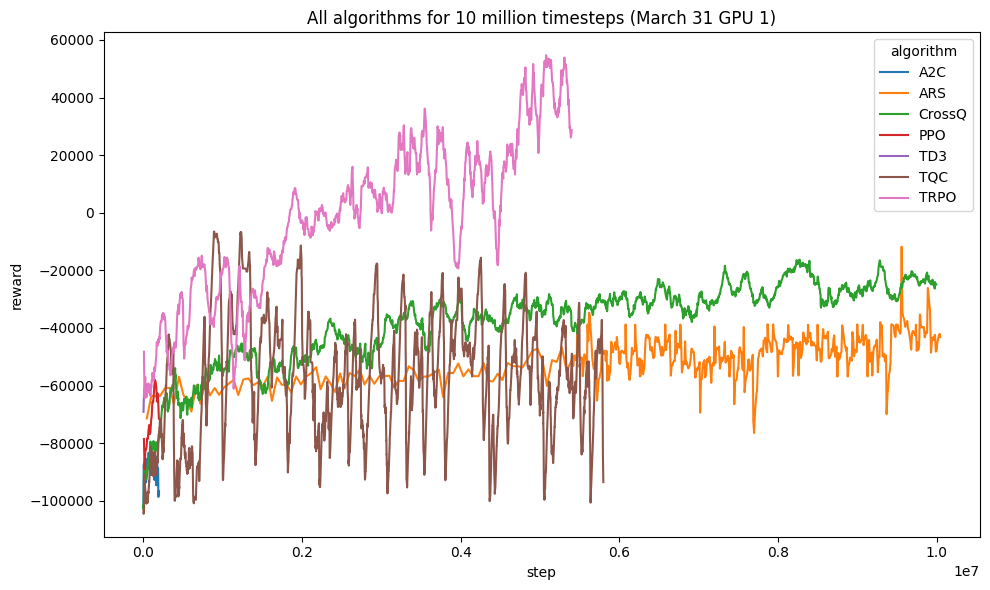

In [7]:
# Gather data
data = []
logs = glob.glob(r"C:\Users\choto\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\from_gpu_server\march31\*\*\*")
for log in logs:
    print(log)
    print(log.split('\\'))
    experiment_info = log.split('\\')[-2].split('_')
    print(experiment_info)
    algorithm = experiment_info[0]
    st = experiment_info[1]

    for e in tf.compat.v1.train.summary_iterator(log):
        for v in e.summary.value:
            if v.tag == 'rollout/ep_rew_mean':
                data.append({
                    'algorithm': algorithm,
                    'set': st,
                    'step': e.step,
                    'reward': v.simple_value
                })
df = pd.DataFrame(data)

# Plot algorithm comparison figure
plt.figure(figsize=(10,6))
plt.title('All algorithms for 10 million timesteps (March 31 GPU 1)')
seaborn.lineplot(data=df, x='step', y='reward', hue='algorithm')
# plt.grid()
plt.tight_layout()
# plt.savefig('a2c.png')
plt.show()

C:\Users\choto\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\from_gpu_server\march25\new_mar25_env3_a2c\A2C_1\events.out.tfevents.1742949765.gpu1.1566318.3
['C:', 'Users', 'choto', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Codes', 'for_coRL', 'from_gpu_server', 'march25', 'new_mar25_env3_a2c', 'A2C_1', 'events.out.tfevents.1742949765.gpu1.1566318.3']
['A2C', '1']
C:\Users\choto\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\from_gpu_server\march25\new_mar25_env3_ars\ARS_1\events.out.tfevents.1742947028.gpu1.1566318.2
['C:', 'Users', 'choto', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Codes', 'for_coRL', 'from_gpu_server', 'march25', 'new_mar25_env3_ars', 'ARS_1', 'events.out.tfevents.1742947028.gpu1.1566318.2']
['ARS', '1']
C:\Users\choto\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\from_gpu_

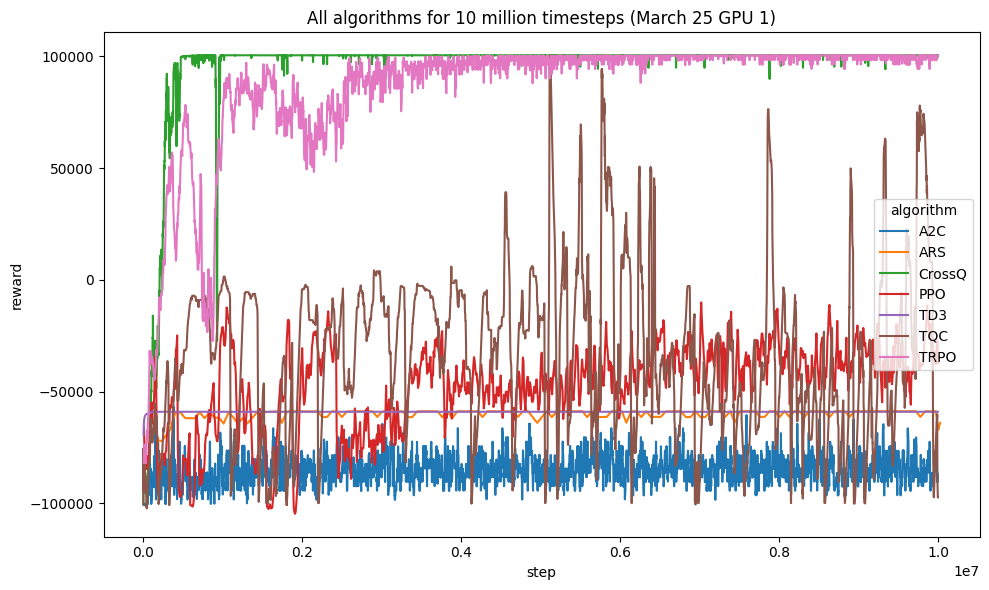

In [8]:
# Gather data
data = []
logs = glob.glob(r"C:\Users\choto\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\from_gpu_server\march25\*\*\*")
for log in logs:
    print(log)
    print(log.split('\\'))
    experiment_info = log.split('\\')[-2].split('_')
    print(experiment_info)
    algorithm = experiment_info[0]
    st = experiment_info[1]

    for e in tf.compat.v1.train.summary_iterator(log):
        for v in e.summary.value:
            if v.tag == 'rollout/ep_rew_mean':
                data.append({
                    'algorithm': algorithm,
                    'set': st,
                    'step': e.step,
                    'reward': v.simple_value
                })
df = pd.DataFrame(data)

# Plot algorithm comparison figure
plt.figure(figsize=(10,6))
plt.title('All algorithms for 10 million timesteps (March 25 GPU 1)')
seaborn.lineplot(data=df, x='step', y='reward', hue='algorithm')
# plt.grid()
plt.tight_layout()
# plt.savefig('a2c.png')
plt.show()

C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\temp\t2\A2C_1\events.out.tfevents.1742247330.kaos5-1.25292.1
['C:', 'Users', 'choton', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Codes', 'for_coRL', 'temp', 't2', 'A2C_1', 'events.out.tfevents.1742247330.kaos5-1.25292.1']
['A2C', '1']
C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\temp\t2\ARS_1\events.out.tfevents.1742265087.kaos5-1.25292.3
['C:', 'Users', 'choton', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Codes', 'for_coRL', 'temp', 't2', 'ARS_1', 'events.out.tfevents.1742265087.kaos5-1.25292.3']
['ARS', '1']
C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\temp\t2\CrossQ_1\events.out.tfevents.1742313344.kaos5-1.25292.5
['C:', 'Users', 'choton', 'OneDrive - Kansas State University', 'PhD Projects', 'R

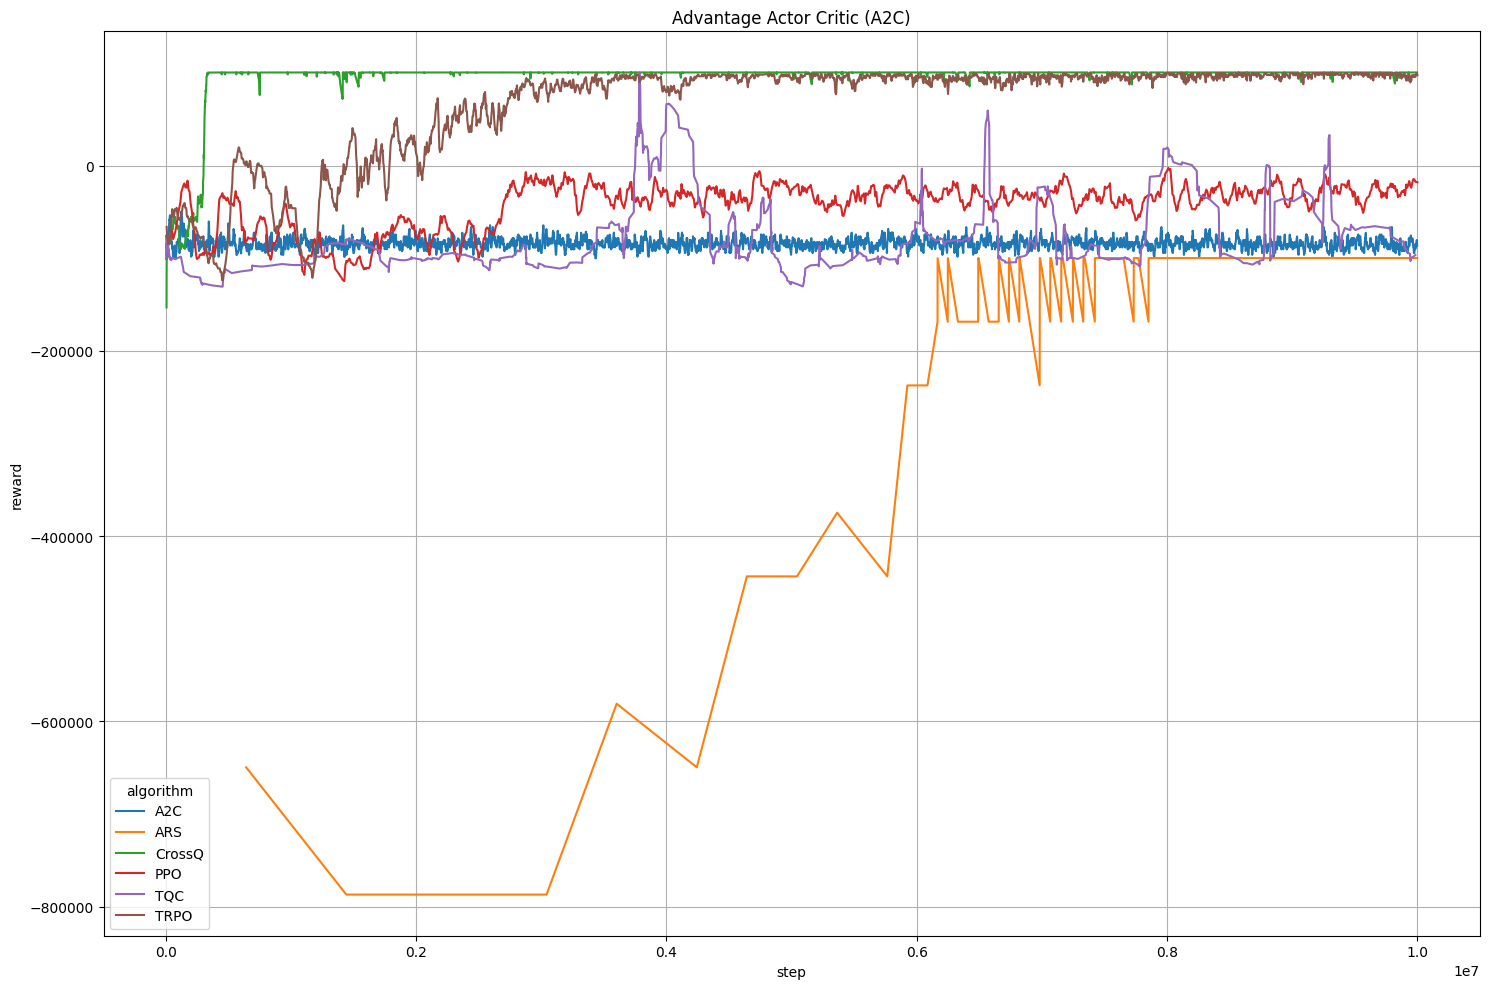

In [11]:
# Gather data
data = []
logs = glob.glob(r"C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Codes\for_coRL\temp\t2\*\*")
for log in logs:
    print(log)
    print(log.split('\\'))
    experiment_info = log.split('\\')[-2].split('_')
    print(experiment_info)
    algorithm = experiment_info[0]
    st = experiment_info[1]

    for e in tf.compat.v1.train.summary_iterator(log):
        for v in e.summary.value:
            if v.tag == 'rollout/ep_rew_mean':
                data.append({
                    'algorithm': algorithm,
                    'set': st,
                    'step': e.step,
                    'reward': v.simple_value
                })
df = pd.DataFrame(data)

# Plot algorithm comparison figure
plt.figure(figsize=(15,10))
plt.title('Advantage Actor Critic (A2C)')
seaborn.lineplot(data=df, x='step', y='reward', hue='algorithm')
plt.grid()
plt.tight_layout()
# plt.savefig('a2c.png')
plt.show()

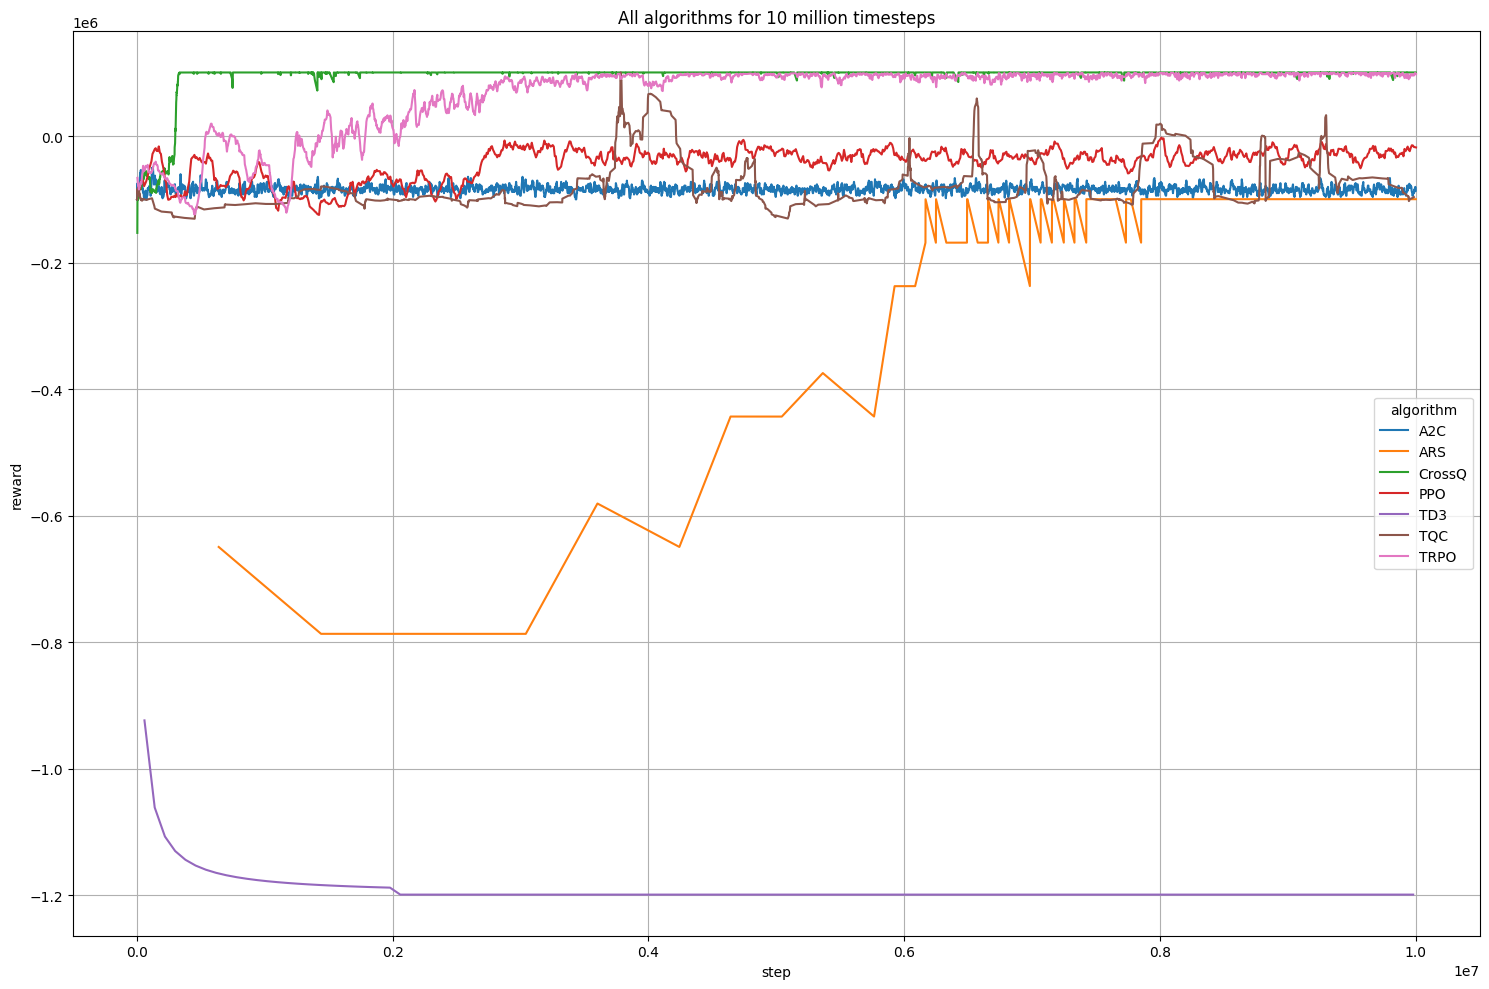

In [9]:
# Plot algorithm comparison figure
plt.figure(figsize=(15,10))
plt.title('All algorithms for 10 million timesteps')
seaborn.lineplot(data=df, x='step', y='reward', hue='algorithm')
plt.grid()
plt.tight_layout()
plt.savefig('env3_all.png')
plt.show()

C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Resubmission\best_working_code\Feb14\tb_logs\a2c_all\A2C_2\events.out.tfevents.1739585473.Black-Bullet.22904.1
['C:', 'Users', 'choton', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Resubmission', 'best_working_code', 'Feb14', 'tb_logs', 'a2c_all', 'A2C_2', 'events.out.tfevents.1739585473.Black-Bullet.22904.1']
['A2C', '2']
C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Resubmission\best_working_code\Feb14\tb_logs\a2c_all\A2C_3\events.out.tfevents.1739586301.Black-Bullet.22904.2
['C:', 'Users', 'choton', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Resubmission', 'best_working_code', 'Feb14', 'tb_logs', 'a2c_all', 'A2C_3', 'events.out.tfevents.1739586301.Black-Bullet.22904.2']
['A2C', '3']
C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Resubmission\be

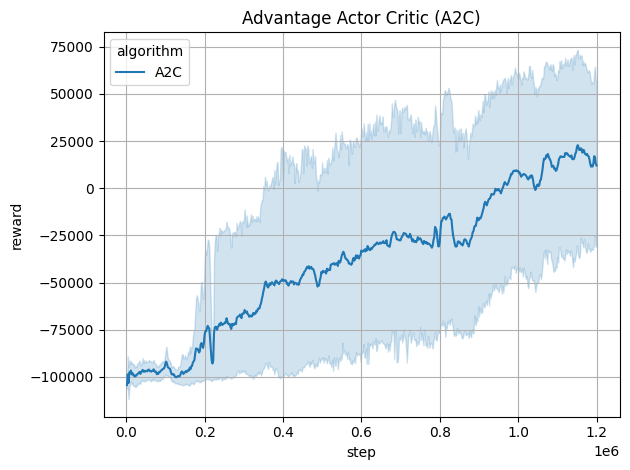

In [ ]:
# Gather data
data = []
logs = glob.glob(r"C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Resubmission\best_working_code\Feb14\tb_logs\a2c_all\*\*")
for log in logs:
    print(log)
    print(log.split('\\'))
    experiment_info = log.split('\\')[-2].split('_')
    print(experiment_info)
    algorithm = experiment_info[0]
    st = experiment_info[1]

    for e in tf.compat.v1.train.summary_iterator(log):
        for v in e.summary.value:
            if v.tag == 'rollout/ep_rew_mean':
                data.append({
                    'algorithm': algorithm,
                    'set': st,
                    'step': e.step,
                    'reward': v.simple_value
                })
df = pd.DataFrame(data)

# Plot algorithm comparison figure
plt.figure()
plt.title('Advantage Actor Critic (A2C)')
seaborn.lineplot(data=df, x='step', y='reward', hue='algorithm')
plt.grid()
plt.tight_layout()
plt.savefig('plotting/plots/a2c.png')

C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Resubmission\best_working_code\Feb14\tb_logs\env1_all\dis_a2c_feb14_optuna\A2C_1\events.out.tfevents.1739570802.DESKTOP-O4FAV6M.17308.0
['C:', 'Users', 'choton', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Resubmission', 'best_working_code', 'Feb14', 'tb_logs', 'env1_all', 'dis_a2c_feb14_optuna', 'A2C_1', 'events.out.tfevents.1739570802.DESKTOP-O4FAV6M.17308.0']
['A2C', '1']
C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Resubmission\best_working_code\Feb14\tb_logs\env1_all\dis_a2c_feb14_optuna\A2C_10\events.out.tfevents.1739577733.DESKTOP-O4FAV6M.17308.9
['C:', 'Users', 'choton', 'OneDrive - Kansas State University', 'PhD Projects', 'Reinforcement Learning', 'Resubmission', 'best_working_code', 'Feb14', 'tb_logs', 'env1_all', 'dis_a2c_feb14_optuna', 'A2C_10', 'events.out.tfevents.1739577733.DESKTOP-O4FAV6M.17308.9']
['A2C',

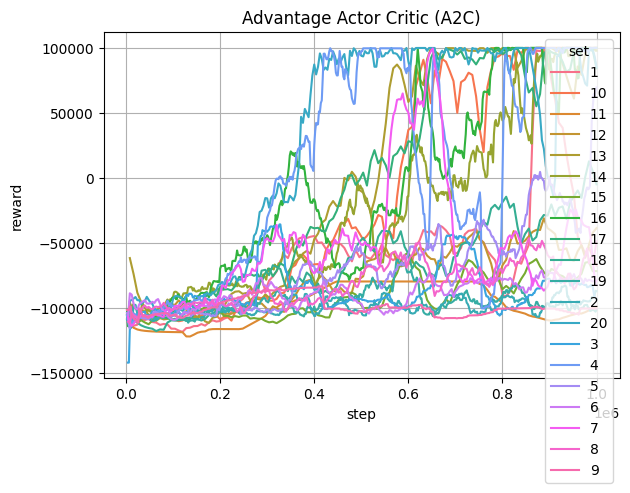

In [ ]:
# Gather data
data = []
logs = glob.glob(r"C:\Users\choton\OneDrive - Kansas State University\PhD Projects\Reinforcement Learning\Resubmission\best_working_code\Feb14\tb_logs\env1_all\dis_a2c_feb14_optuna\*\*")
for log in logs:
    print(log)
    print(log.split('\\'))
    experiment_info = log.split('\\')[-2].split('_')
    print(experiment_info)
    algorithm = experiment_info[0]
    st = experiment_info[1]

    for e in tf.compat.v1.train.summary_iterator(log):
        for v in e.summary.value:
            if v.tag == 'rollout/ep_rew_mean':
                data.append({
                    'algorithm': algorithm,
                    'set': st,
                    'step': e.step,
                    'reward': v.simple_value
                })
df = pd.DataFrame(data)

# Plot algorithm comparison figure
plt.figure()
plt.title('Advantage Actor Critic (A2C)')
seaborn.lineplot(data=df, x='step', y='reward', hue='set')
plt.grid()
plt.tight_layout()
plt.savefig('plotting/plots/a2c.png')